<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/DENSE_NET_201_SVM_TRAINABLE%20WITH%20GRAPHS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
import itertools
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print('Modules loaded.')


Modules loaded.


In [55]:
# Generate data paths with labels
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)


In [57]:
df

,filepaths,labels
0,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
1,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
2,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
3,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
4,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
...,...,...
1573,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1574,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1575,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1576,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant


In [58]:
strat = df['labels']
train_df, test_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

In [59]:
test_df

,filepaths,labels
133,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
481,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
372,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
605,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
571,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
...,...,...
1444,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1413,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
726,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
218,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal


In [60]:
# Load DenseNet201 model for feature extraction
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Unfreeze the last few layers of DenseNet201
for layer in base_model.layers[-20:]:  # Unfreeze the last 20 layers
    layer.trainable = True

# Function to load and preprocess images
def load_and_preprocess_images(filepaths, img_size=(224, 224)):
    images = []
    for filepath in filepaths:
        img = cv2.imread(filepath)
        img = cv2.resize(img, img_size)
        img = img.astype('float32')  # Convert to float32
        img = preprocess_input(img)  # Preprocess for DenseNet201
        images.append(img)
    return np.array(images)

# Load training and testing images
X_train = load_and_preprocess_images(train_df['filepaths'].values)
y_train = train_df['labels'].values
X_test = load_and_preprocess_images(test_df['filepaths'].values)
y_test = test_df['labels'].values


In [61]:
# Extract features using efficient net b3
X_train_features = base_model.predict(X_train)
X_test_features = base_model.predict(X_test)

# Flatten the features
X_train_features = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_features = X_test_features.reshape(X_test_features.shape[0], -1)

40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 586ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


In [62]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [63]:
# Train the SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=43, probability=True)  # Enable probability for ROC curve
svm_model.fit(X_train_features, y_train_encoded)


SVC(kernel='linear', probability=True, random_state=43)

In [64]:
# Make predictions
y_pred = svm_model.predict(X_test_features)
y_pred_proba = svm_model.predict_proba(X_test_features)  # Probabilities for ROC curve

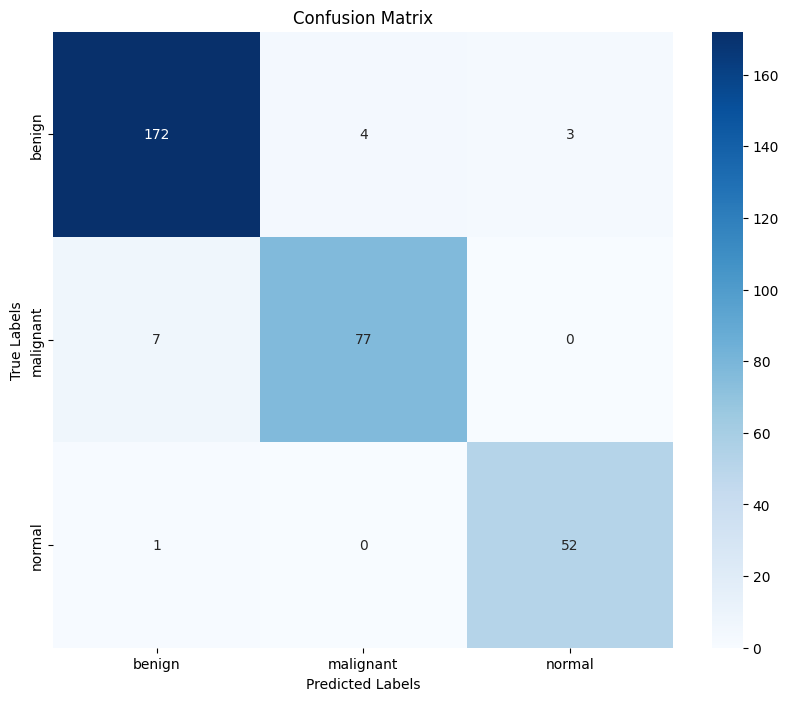

In [65]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

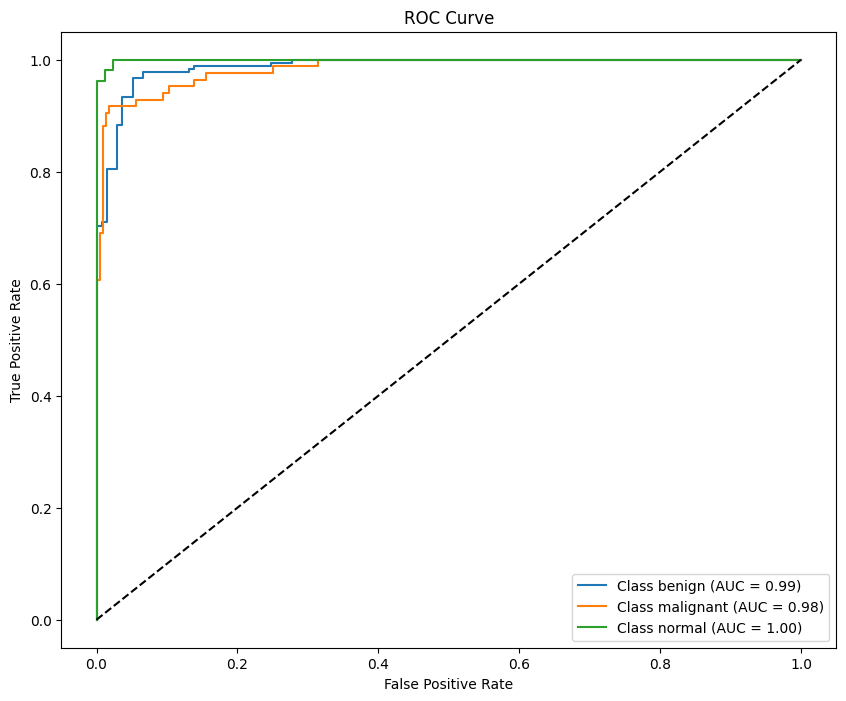

In [68]:
# 2. ROC Curve and AUC Score
plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

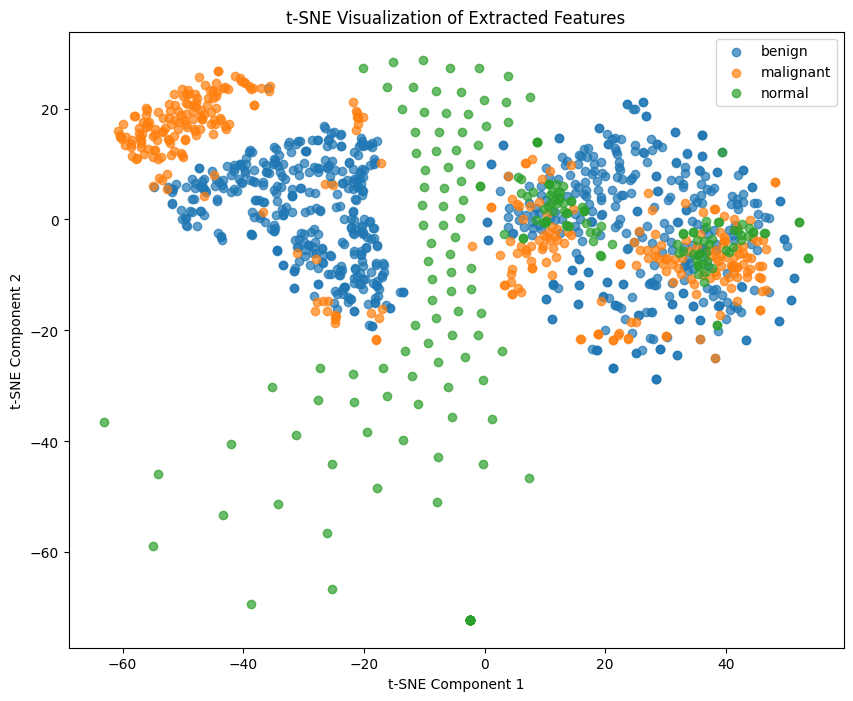

In [69]:
# 4. t-SNE Visualization of Extracted Features
tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_features)

plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    indices = np.where(y_train_encoded == i)
    plt.scatter(X_train_tsne[indices, 0], X_train_tsne[indices, 1], label=le.classes_[i], alpha=0.7)
plt.title('t-SNE Visualization of Extracted Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()

In [ ]:
# Classification report
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      benign       0.96      0.96      0.96       179
   malignant       0.95      0.92      0.93        84
      normal       0.95      0.98      0.96        53

    accuracy                           0.95       316
   macro avg       0.95      0.95      0.95       316
weighted avg       0.95      0.95      0.95       316



In [ ]:
# Save the model using joblib
import joblib
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']